# Forecasting Platform Demo

End-to-end demonstration of the weekly sales forecasting platform.

**What this notebook does:**
1. Generates realistic synthetic retail demand data (8 SKUs, 2.5 years of weekly history)
2. Runs walk-forward backtesting across 4 model families (Naive, ETS, ARIMA, LightGBM)
3. Selects a champion model based on WMAPE
4. Generates a 13-week production forecast
5. Visualizes results: model comparison, forecast vs actual, seasonal decomposition

**No external data required** — synthetic data is generated inline.  
**Expected runtime:** ~2–3 minutes.

In [1]:
import sys
import os
import tempfile
import logging
from datetime import date, timedelta

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# Add the forecasting-platform root to the path so we can import src modules
# (works whether you run from notebooks/ or from the repo root)
platform_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if platform_root not in sys.path:
    sys.path.insert(0, platform_root)

from src.config.schema import PlatformConfig, ForecastConfig, BacktestConfig, OutputConfig
from src.pipeline.backtest import BacktestPipeline
from src.pipeline.forecast import ForecastPipeline
from src.analytics.explainer import ForecastExplainer

# Configure logging so pipeline progress is visible
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

# Matplotlib settings
%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (12, 4)})

print("Imports complete.")

Imports complete.


## 1. Generate Synthetic Retail Data

We create 8 SKUs with realistic demand patterns: varying base volumes, trends,
Q4 holiday lifts, and noise levels.

In [2]:
def generate_retail_data(n_weeks: int = 130, seed: int = 42) -> pl.DataFrame:
    """Generate synthetic weekly retail demand for 8 SKUs."""
    rng = np.random.RandomState(seed)
    start_date = date(2022, 1, 2)  # Sunday (aligns with pandas "W" freq used by mlforecast)

    skus = [
        # (name, base_volume, trend_per_week, noise_pct, category)
        ("ELEC-TV-55",     1800, 3.0,  0.10, "Electronics"),
        ("ELEC-LAPTOP-14", 1200, 1.5,  0.12, "Electronics"),
        ("ELEC-HEADPHONE",  600, 0.0,  0.08, "Electronics"),
        ("APRL-JACKET-M",   400, -1.0, 0.15, "Apparel"),
        ("APRL-SNEAKER-L",  900, 2.0,  0.10, "Apparel"),
        ("HOME-CANDLE-LG",  300, 0.5,  0.12, "Home"),
        ("HOME-BLANKET-Q",  500, -1.5, 0.14, "Home"),
        ("HOME-MUG-SET",    150, 0.0,  0.09, "Home"),
    ]

    rows = []
    for name, base, trend, noise, category in skus:
        for w in range(n_weeks):
            week_date = start_date + timedelta(weeks=w)
            month = week_date.month

            # Seasonal multiplier
            if month in (11, 12):       # Holiday peak
                seasonal = 1.35
            elif month == 10:           # Pre-holiday ramp
                seasonal = 1.15
            elif month in (6, 7):       # Summer bump
                seasonal = 1.08
            elif month == 1:            # Post-holiday dip
                seasonal = 0.85
            else:
                seasonal = 1.0

            value = (base + trend * w) * seasonal
            value += rng.normal(0, base * noise)
            value = max(value, 0)  # no negative demand

            rows.append({
                "series_id": name,
                "week": week_date,
                "quantity": round(value, 1),
            })

    return pl.DataFrame(rows).with_columns(pl.col("week").cast(pl.Date))


actuals = generate_retail_data()
n_series = actuals["series_id"].n_unique()
date_range = f"{actuals['week'].min()} to {actuals['week'].max()}"

print(f"Generated {len(actuals):,} rows: {n_series} series, {date_range}")
print(f"\nSeries summary:")
summary = (
    actuals.group_by("series_id")
    .agg([
        pl.col("quantity").mean().alias("avg_weekly_qty"),
        pl.col("quantity").std().alias("std_qty"),
        pl.len().alias("n_weeks"),
    ])
    .sort("avg_weekly_qty", descending=True)
)
print(summary)

Generated 1,040 rows: 8 series, 2022-01-02 to 2024-06-23

Series summary:
shape: (8, 4)
┌────────────────┬────────────────┬────────────┬─────────┐
│ series_id      ┆ avg_weekly_qty ┆ std_qty    ┆ n_weeks │
│ ---            ┆ ---            ┆ ---        ┆ ---     │
│ str            ┆ f64            ┆ f64        ┆ u32     │
╞════════════════╪════════════════╪════════════╪═════════╡
│ ELEC-TV-55     ┆ 2092.646923    ┆ 332.117157 ┆ 130     │
│ ELEC-LAPTOP-14 ┆ 1380.76        ┆ 253.615901 ┆ 130     │
│ APRL-SNEAKER-L ┆ 1081.155385    ┆ 206.586721 ┆ 130     │
│ ELEC-HEADPHONE ┆ 634.833077     ┆ 96.997978  ┆ 130     │
│ HOME-BLANKET-Q ┆ 439.186154     ┆ 89.973889  ┆ 130     │
│ HOME-CANDLE-LG ┆ 350.483846     ┆ 60.148726  ┆ 130     │
│ APRL-JACKET-M  ┆ 350.414615     ┆ 85.200476  ┆ 130     │
│ HOME-MUG-SET   ┆ 159.299231     ┆ 25.92695   ┆ 130     │
└────────────────┴────────────────┴────────────┴─────────┘


## 2. Visualize Historical Demand

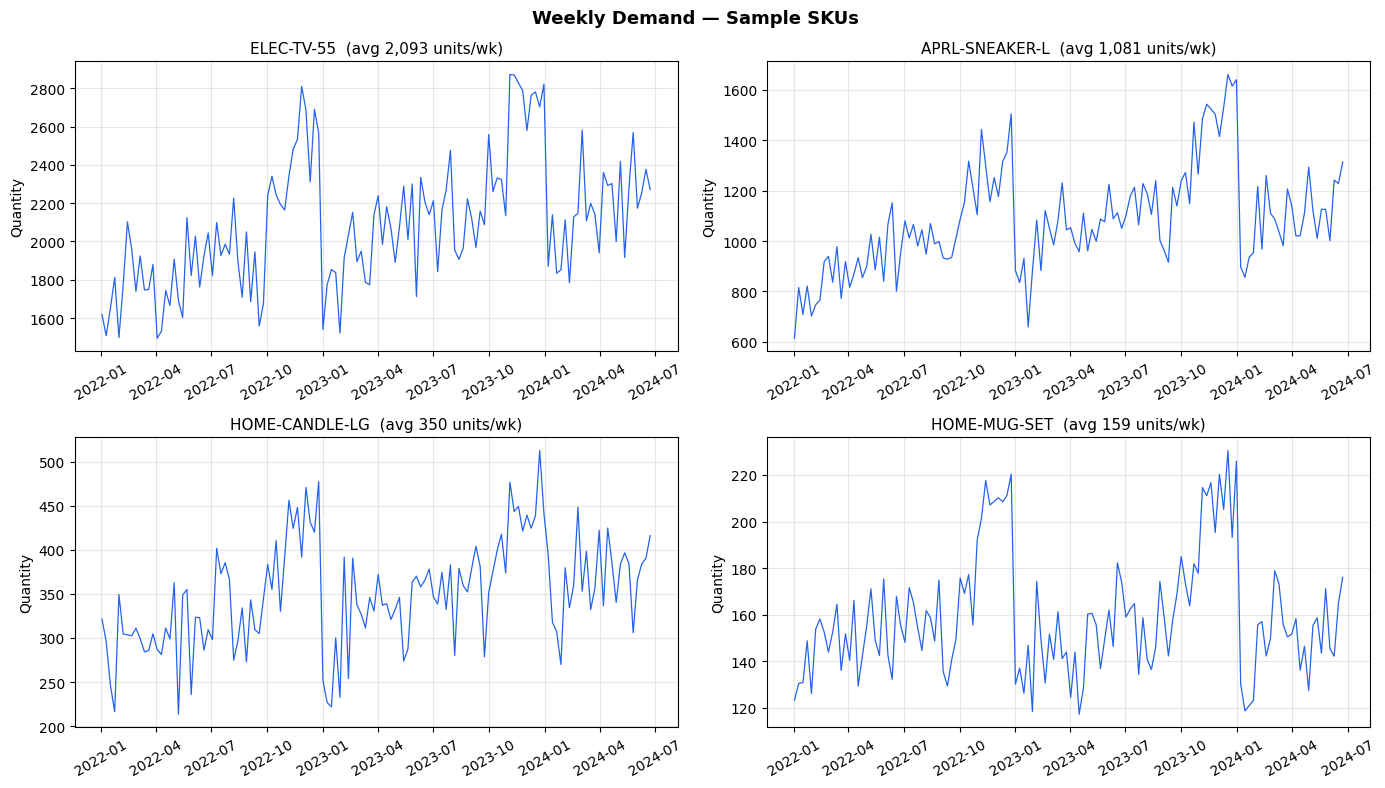

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sample_skus = ["ELEC-TV-55", "APRL-SNEAKER-L", "HOME-CANDLE-LG", "HOME-MUG-SET"]

for ax, sku in zip(axes.flat, sample_skus):
    s = actuals.filter(pl.col("series_id") == sku).sort("week")
    avg = s["quantity"].mean()
    ax.plot(s["week"].to_list(), s["quantity"].to_list(), linewidth=0.9, color="#2563eb")
    ax.set_title(f"{sku}  (avg {avg:,.0f} units/wk)", fontsize=11)
    ax.set_ylabel("Quantity")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3)

fig.suptitle("Weekly Demand — Sample SKUs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Configure the Platform

Build the config programmatically — no YAML files needed. We test 4 model families:
- **Seasonal Naive** — last-year same-week baseline
- **Auto ETS** — exponential smoothing (trend + seasonality)
- **Auto ARIMA** — autoregressive integrated moving average
- **LightGBM Direct** — gradient-boosted trees with lag/rolling features

In [4]:
# Temp directories so pipeline file writes don't pollute the workspace
tmpdir = tempfile.mkdtemp(prefix="forecast_demo_")

config = PlatformConfig(
    lob="retail_demo",
    description="Demo run on synthetic retail data",
    forecast=ForecastConfig(
        horizon_weeks=13,
        frequency="W",
        target_column="quantity",
        time_column="week",
        series_id_column="series_id",
        forecasters=["naive_seasonal", "auto_ets", "auto_arima", "lgbm_direct"],
    ),
    backtest=BacktestConfig(
        n_folds=3,
        val_weeks=13,
        gap_weeks=0,
        primary_metric="wmape",
        secondary_metric="normalized_bias",
        champion_granularity="lob",
        selection_strategy="champion",
    ),
    output=OutputConfig(
        forecast_path=os.path.join(tmpdir, "forecasts"),
        metrics_path=os.path.join(tmpdir, "metrics"),
        bi_export_path=os.path.join(tmpdir, "bi_exports"),
    ),
    metrics=["wmape", "normalized_bias"],
)

print(f"Config ready.")
print(f"  Models: {config.forecast.forecasters}")
print(f"  Backtest: {config.backtest.n_folds} folds x {config.backtest.val_weeks} weeks")
print(f"  Horizon: {config.forecast.horizon_weeks} weeks")
print(f"  Temp dir: {tmpdir}")

Config ready.
  Models: ['naive_seasonal', 'auto_ets', 'auto_arima', 'lgbm_direct']
  Backtest: 3 folds x 13 weeks
  Horizon: 13 weeks
  Temp dir: /tmp/forecast_demo_0vu8rquu


## 4. Run Walk-Forward Backtest

The backtest engine runs 3-fold walk-forward cross-validation:
each fold trains on expanding history and validates on the next 13 weeks.
All 4 models are evaluated on every fold.

In [5]:
pipeline = BacktestPipeline(config)
results = pipeline.run(actuals)

backtest_results = results["backtest_results"]
champions = results["champions"]

# Extract champion info
champion_row = champions.head(1).to_dicts()[0]
champion_name = champion_row["model_id"]
champion_wmape = champion_row["wmape"]

print("\n" + "=" * 70)
print(f"CHAMPION MODEL: {champion_name}")
print(f"  WMAPE: {champion_wmape:.1%}")
print(f"  Selected from {len(config.forecast.forecasters)} models across "
      f"{config.backtest.n_folds}-fold walk-forward backtest on {n_series} series")
print("=" * 70)

INFO | Building model-ready series...


INFO | Series built: 1040 rows, 8 series


INFO | Forecasters: ['naive_seasonal', 'auto_ets', 'auto_arima', 'lgbm_direct']


INFO | Running backtesting (3 folds)...


INFO | Fold 0: train 2022-01-02→2023-09-24, val 2023-10-01→2023-12-24 (728/104 train/val rows)


...

INFO | Selecting champion model(s)...


INFO | Champion selection (lob): 1 group(s)


INFO |   retail_demo → lgbm_direct (WMAPE=0.1421, Bias=-0.0223)


INFO | Backtest pipeline complete.



CHAMPION MODEL: lgbm_direct
  WMAPE: 14.2%
  Selected from 4 models across 3-fold walk-forward backtest on 8 series


## 5. Model Leaderboard

In [6]:
leaderboard = (
    backtest_results
    .group_by("model_id")
    .agg([
        pl.col("wmape").mean().alias("mean_wmape"),
        pl.col("normalized_bias").mean().alias("mean_bias"),
        pl.col("wmape").std().alias("wmape_std"),
        pl.len().alias("n_observations"),
    ])
    .sort("mean_wmape")
)

print("Model Leaderboard (ranked by WMAPE, lower is better):")
print("-" * 70)
print(f"{'Rank':<5} {'Model':<20} {'WMAPE':>10} {'Bias':>10} {'WMAPE Std':>10}")
print("-" * 70)
for rank, row in enumerate(leaderboard.iter_rows(named=True), 1):
    marker = " <<< champion" if row["model_id"] == champion_name else ""
    print(f"{rank:<5} {row['model_id']:<20} {row['mean_wmape']:>9.1%} "
          f"{row['mean_bias']:>+9.1%}  {row['wmape_std']:>9.3f}{marker}")
print("-" * 70)

Model Leaderboard (ranked by WMAPE, lower is better):
----------------------------------------------------------------------
Rank  Model                     WMAPE       Bias  WMAPE Std
----------------------------------------------------------------------
1     lgbm_direct              14.2%     -2.2%      0.049 <<< champion
2     naive_seasonal           14.9%     -1.2%      0.075
3     auto_ets                 21.9%     +5.7%      0.119
4     auto_arima               22.4%     +7.2%      0.117
----------------------------------------------------------------------


## 6. Model Comparison

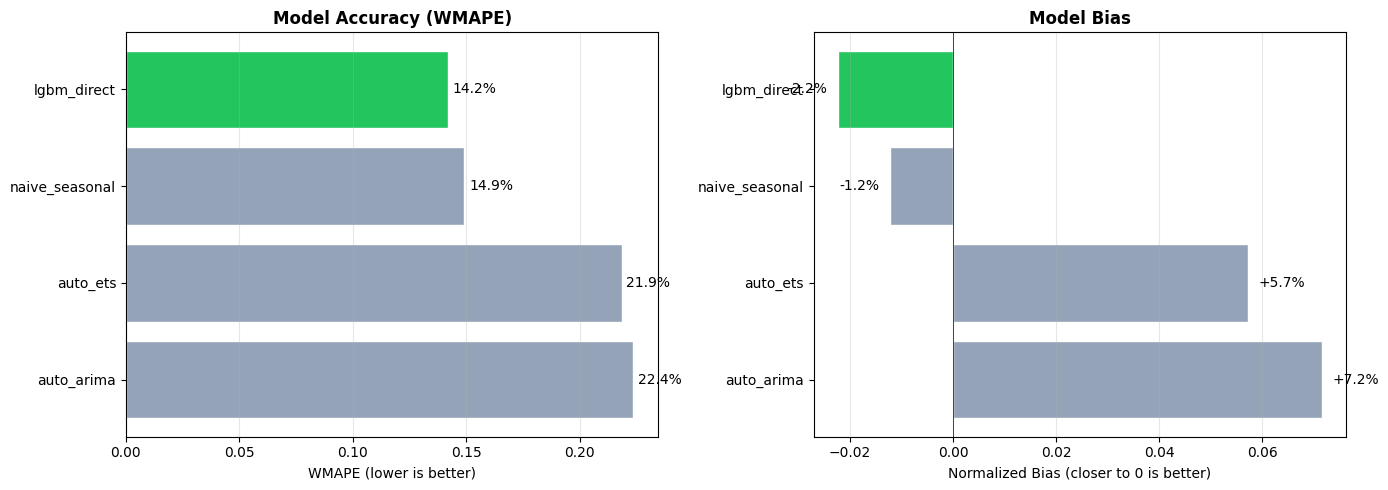

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = leaderboard["model_id"].to_list()
wmapes = leaderboard["mean_wmape"].to_list()
biases = leaderboard["mean_bias"].to_list()
colors = ["#22c55e" if m == champion_name else "#94a3b8" for m in models]

# WMAPE bar chart
bars = ax1.barh(models, wmapes, color=colors, edgecolor="white")
for bar, val in zip(bars, wmapes):
    ax1.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
             f"{val:.1%}", va="center", fontsize=10)
ax1.set_xlabel("WMAPE (lower is better)")
ax1.set_title("Model Accuracy (WMAPE)", fontweight="bold")
ax1.invert_yaxis()
ax1.grid(True, axis="x", alpha=0.3)

# Bias bar chart
bars2 = ax2.barh(models, biases, color=colors, edgecolor="white")
for bar, val in zip(bars2, biases):
    offset = 0.002 if val >= 0 else -0.002
    ha = "left" if val >= 0 else "right"
    ax2.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
             f"{val:+.1%}", va="center", ha=ha, fontsize=10)
ax2.axvline(0, color="black", linewidth=0.5)
ax2.set_xlabel("Normalized Bias (closer to 0 is better)")
ax2.set_title("Model Bias", fontweight="bold")
ax2.invert_yaxis()
ax2.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Per-Fold Stability

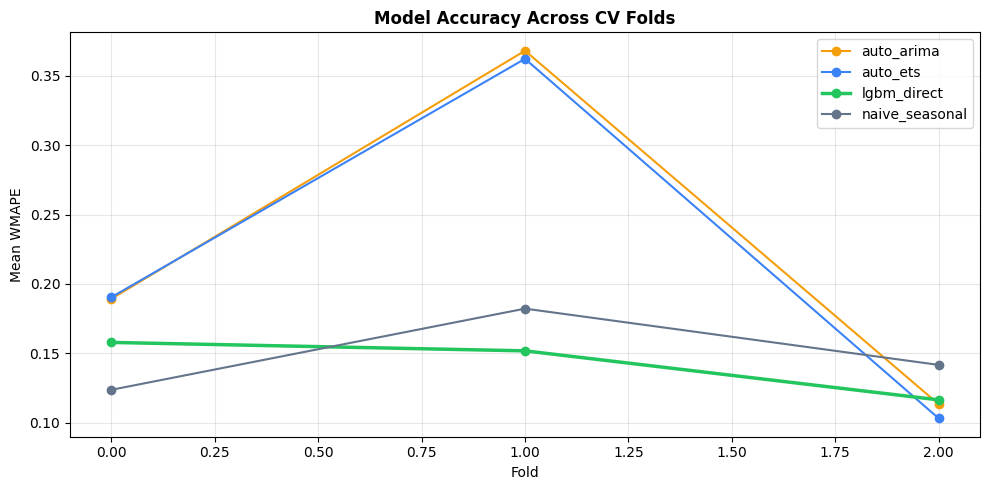

In [8]:
fold_metrics = (
    backtest_results
    .group_by(["model_id", "fold"])
    .agg(pl.col("wmape").mean().alias("mean_wmape"))
    .sort(["model_id", "fold"])
)

fig, ax = plt.subplots(figsize=(10, 5))
model_colors = {"naive_seasonal": "#64748b", "auto_ets": "#3b82f6",
                "auto_arima": "#f59e0b", "lgbm_direct": "#22c55e"}

for model in fold_metrics["model_id"].unique().sort().to_list():
    m = fold_metrics.filter(pl.col("model_id") == model)
    folds = m["fold"].to_list()
    vals = m["mean_wmape"].to_list()
    color = model_colors.get(model, "#94a3b8")
    lw = 2.5 if model == champion_name else 1.5
    ax.plot(folds, vals, marker="o", label=model, color=color, linewidth=lw)

ax.set_xlabel("Fold")
ax.set_ylabel("Mean WMAPE")
ax.set_title("Model Accuracy Across CV Folds", fontweight="bold")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Backtest Forecast vs Actual

Overlay the champion model's backtest predictions against actuals.

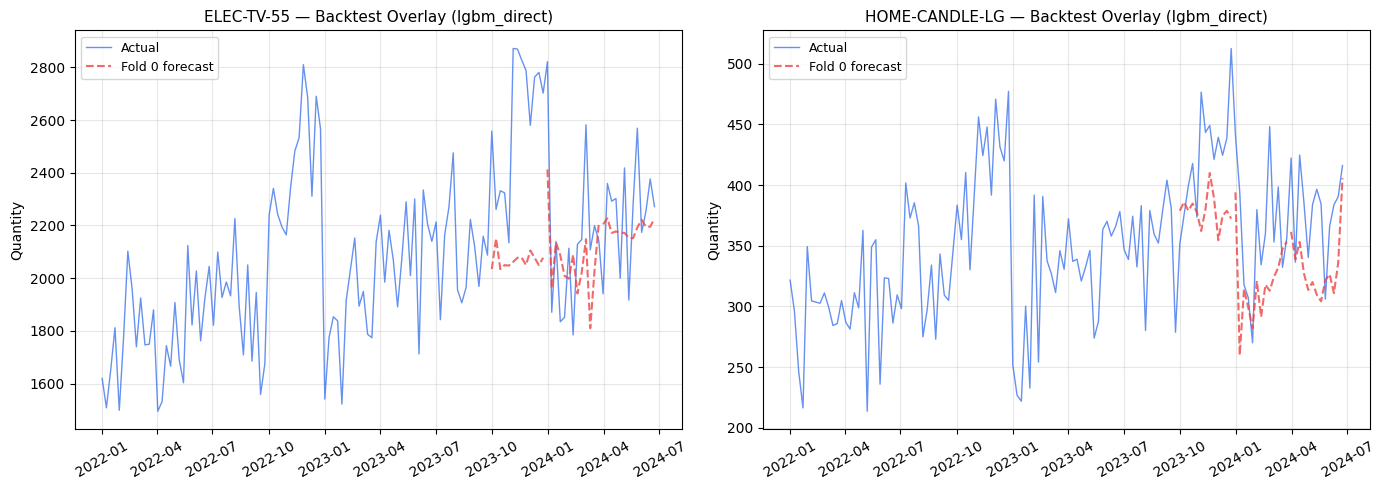

In [9]:
champion_bt = backtest_results.filter(pl.col("model_id") == champion_name)
overlay_skus = ["ELEC-TV-55", "HOME-CANDLE-LG"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sku in zip(axes, overlay_skus):
    # Full actuals
    hist = actuals.filter(pl.col("series_id") == sku).sort("week")
    ax.plot(hist["week"].to_list(), hist["quantity"].to_list(),
            color="#2563eb", linewidth=1, label="Actual", alpha=0.7)

    # Backtest predictions per fold
    bt = champion_bt.filter(pl.col("series_id") == sku).sort("target_week")
    if not bt.is_empty():
        for fold_idx in bt["fold"].unique().sort().to_list():
            fold_data = bt.filter(pl.col("fold") == fold_idx).sort("target_week")
            label = f"Fold {fold_idx} forecast" if fold_idx == 0 else None
            ax.plot(fold_data["target_week"].to_list(),
                    fold_data["forecast"].to_list(),
                    color="#ef4444", linewidth=1.5, alpha=0.8,
                    linestyle="--", label=label)

    ax.set_title(f"{sku} — Backtest Overlay ({champion_name})", fontsize=11)
    ax.set_ylabel("Quantity")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Production Forecast

Generate a 13-week forward forecast using the champion model fitted on all available history.

In [10]:
forecast_pipeline = ForecastPipeline(config)
forecast_df = forecast_pipeline.run(actuals, champion_model=champion_name)

print(f"\nForecast generated: {len(forecast_df)} rows")
print(f"  Series: {forecast_df['series_id'].n_unique()}")
print(f"  Date range: {forecast_df['week'].min()} to {forecast_df['week'].max()}")
print(f"  Champion model: {champion_name}")
print(f"\nSample forecast rows:")
print(forecast_df.head(10))

INFO | Building model-ready series...


INFO | Champion model: lgbm_direct


INFO | Fitting on 1040 rows...


INFO | Forecasting 13 weeks...


INFO | Forecast written to /tmp/forecast_demo_0vu8rquu/forecasts/forecast_retail_demo_2026-03-14.parquet (104 rows)



Forecast generated: 104 rows
  Series: 8
  Date range: 2024-06-30 to 2024-09-22
  Champion model: lgbm_direct

Sample forecast rows:
shape: (10, 3)
┌───────────────┬────────────┬────────────┐
│ series_id     ┆ week       ┆ forecast   │
│ ---           ┆ ---        ┆ ---        │
│ str           ┆ date       ┆ f64        │
╞═══════════════╪════════════╪════════════╡
│ APRL-JACKET-M ┆ 2024-06-30 ┆ 366.416713 │
│ APRL-JACKET-M ┆ 2024-07-07 ┆ 315.085135 │
│ APRL-JACKET-M ┆ 2024-07-14 ┆ 277.466136 │
│ APRL-JACKET-M ┆ 2024-07-21 ┆ 320.793625 │
│ APRL-JACKET-M ┆ 2024-07-28 ┆ 325.968679 │
│ APRL-JACKET-M ┆ 2024-08-04 ┆ 285.971298 │
│ APRL-JACKET-M ┆ 2024-08-11 ┆ 295.128176 │
│ APRL-JACKET-M ┆ 2024-08-18 ┆ 293.681364 │
│ APRL-JACKET-M ┆ 2024-08-25 ┆ 343.060337 │
│ APRL-JACKET-M ┆ 2024-09-01 ┆ 384.967224 │
└───────────────┴────────────┴────────────┘


## 10. Forecast Visualization

Last 52 weeks of history + 13-week forward forecast for 4 representative SKUs.

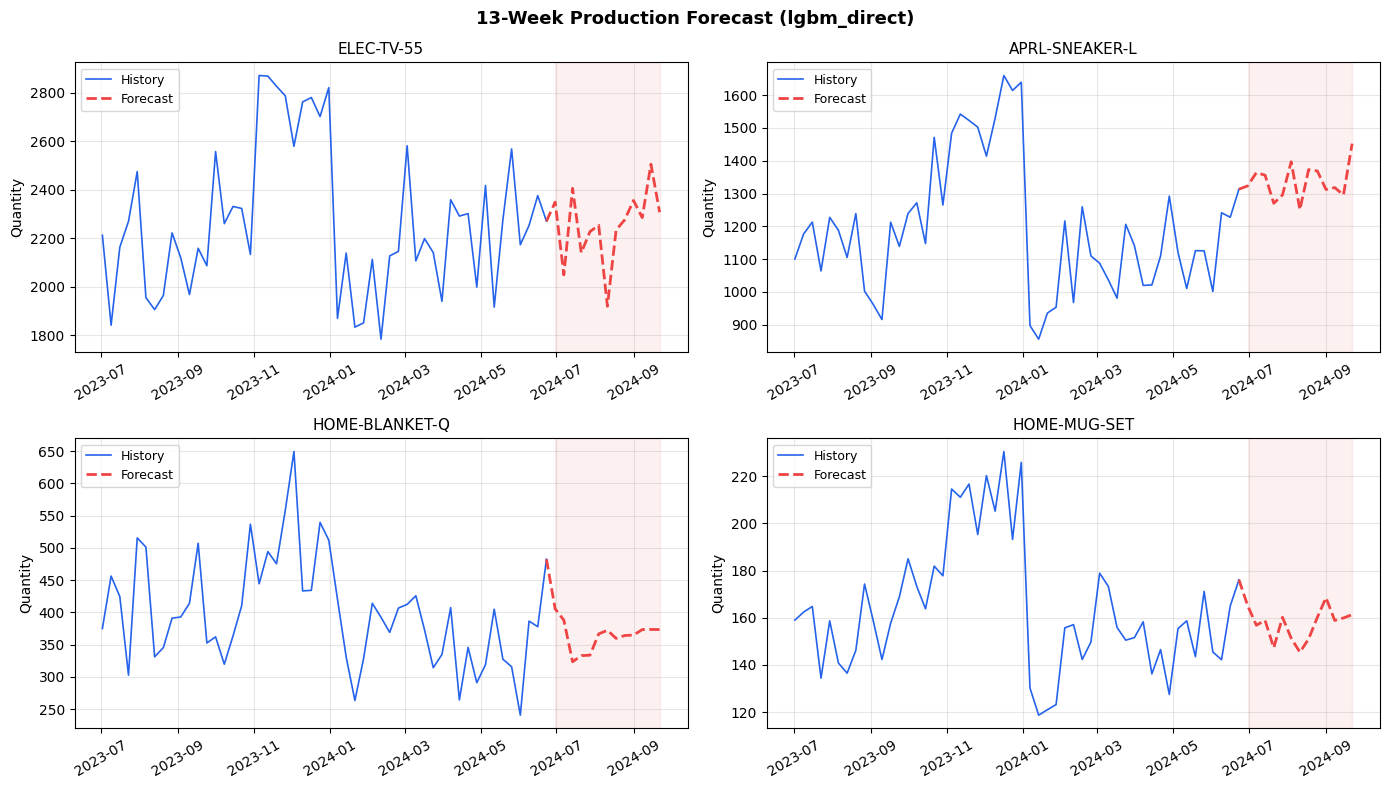

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
viz_skus = ["ELEC-TV-55", "APRL-SNEAKER-L", "HOME-BLANKET-Q", "HOME-MUG-SET"]

for ax, sku in zip(axes.flat, viz_skus):
    # Last 52 weeks of history
    hist = actuals.filter(pl.col("series_id") == sku).sort("week").tail(52)
    fc = forecast_df.filter(pl.col("series_id") == sku).sort("week")

    ax.plot(hist["week"].to_list(), hist["quantity"].to_list(),
            color="#2563eb", linewidth=1.2, label="History")

    # Connect history to forecast with a bridge point
    bridge_week = hist["week"].to_list()[-1]
    bridge_qty = hist["quantity"].to_list()[-1]
    fc_weeks = [bridge_week] + fc["week"].to_list()
    fc_vals = [bridge_qty] + fc["forecast"].to_list()

    ax.plot(fc_weeks, fc_vals,
            color="#ef4444", linewidth=2, linestyle="--", label="Forecast")

    # Shade forecast region
    ax.axvspan(fc["week"].min(), fc["week"].max(),
               alpha=0.08, color="#ef4444")

    ax.set_title(sku, fontsize=11)
    ax.set_ylabel("Quantity")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"13-Week Production Forecast ({champion_name})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Seasonal Decomposition

Break down one SKU's demand into trend, seasonal, and residual components
using the platform's built-in explainability module.

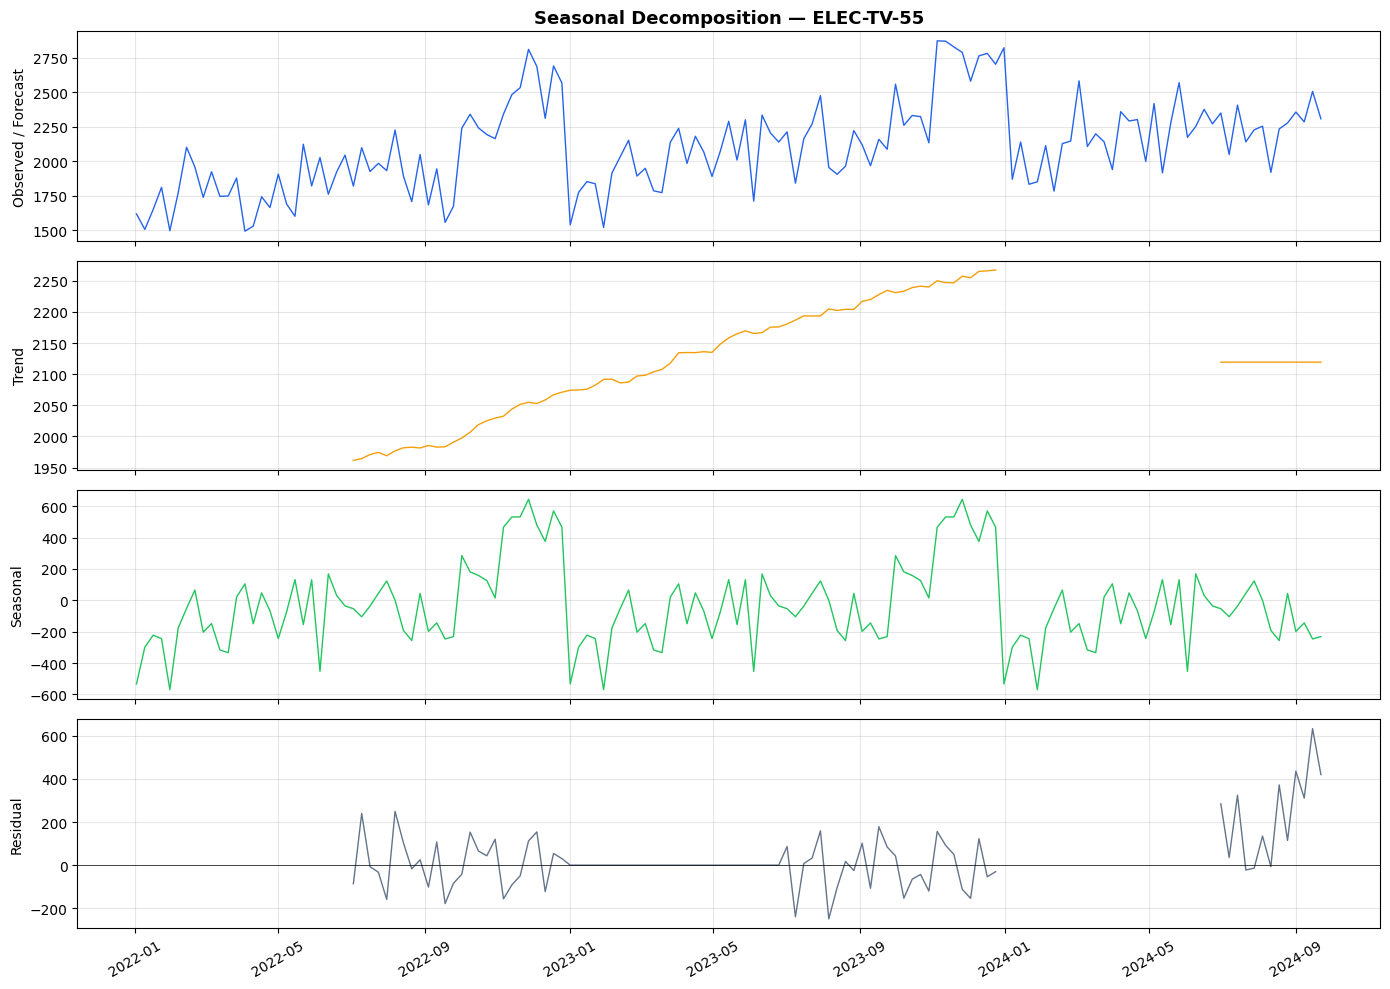

In [12]:
explainer = ForecastExplainer(season_length=52, trend_window=12)

decomp_sku = "ELEC-TV-55"
history = actuals.filter(pl.col("series_id") == decomp_sku)
fc_single = forecast_df.filter(pl.col("series_id") == decomp_sku)

decomp = explainer.decompose(
    history=history,
    forecast=fc_single,
    id_col="series_id",
    time_col="week",
    target_col="quantity",
    value_col="forecast",
)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
weeks = decomp["week"].to_list()

components = [
    ("value", "Observed / Forecast", "#2563eb"),
    ("trend", "Trend", "#f59e0b"),
    ("seasonal", "Seasonal", "#22c55e"),
    ("residual", "Residual", "#64748b"),
]

for ax, (col, title, color) in zip(axes, components):
    if col in decomp.columns:
        vals = decomp[col].to_list()
        ax.plot(weeks, vals, color=color, linewidth=1)
        ax.set_ylabel(title, fontsize=10)
        ax.grid(True, alpha=0.3)
        if col == "residual":
            ax.axhline(0, color="black", linewidth=0.5)

axes[0].set_title(f"Seasonal Decomposition — {decomp_sku}", fontsize=13, fontweight="bold")
axes[-1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the platform's core workflow:

| Step | What | Result |
|------|------|--------|
| **Data** | 8 synthetic retail SKUs, 130 weeks | Trend, seasonality, noise |
| **Backtest** | 3-fold walk-forward CV, 4 model families | Per-model WMAPE and bias |
| **Champion** | Auto-selected by lowest WMAPE | See leaderboard above |
| **Forecast** | 13-week forward projection | Production-ready output |
| **Explainability** | STL-style decomposition | Trend/seasonal/residual |

### Platform capabilities not shown here
- Hierarchical reconciliation (OLS / WLS / MinT)
- Sparse demand routing (Croston, TSB) for intermittent SKUs
- Product transition stitching (new/discontinued SKU mapping)
- Planner override management (DuckDB store)
- SHAP-based ML feature attribution
- Forecast Value Added (FVA) analysis
- REST API with RBAC authentication
- PySpark distributed execution for large-scale deployments

See the [README](../README.md) for full architecture documentation.

In [13]:
# Cleanup temp directory
import shutil
shutil.rmtree(tmpdir, ignore_errors=True)
print(f"Cleaned up temp directory: {tmpdir}")

Cleaned up temp directory: /tmp/forecast_demo_0vu8rquu
